# Modeling: Workplace Safety Risk Classification

This notebook trains and evaluates classification models to identify high-risk workplace establishments.


## 1. Imports

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

## 2. File Paths

In [2]:
BASE_DIR = Path(".")
OUTPUT_DIR = BASE_DIR / "outputs"
EDA_OUTPUT_DIR = BASE_DIR / "eda_outputs"

candidate_files = [
    OUTPUT_DIR / "model_dataset_strict.csv",
    EDA_OUTPUT_DIR / "model_dataset_strict.csv",
    BASE_DIR / "model_dataset_strict.csv"
]

MODEL_DATA_FILE = None

for file in candidate_files:
    if file.exists():
        MODEL_DATA_FILE = file
        break

MODEL_DATA_FILE

WindowsPath('eda_outputs/model_dataset_strict.csv')

## 3. Load Modeling Dataset

In [3]:
if MODEL_DATA_FILE is None:
    raise FileNotFoundError(
        "Could not find model_dataset_strict.csv. "
        "Check your output folder or update MODEL_DATA_FILE manually."
    )

model_df = pd.read_csv(MODEL_DATA_FILE)

print(f"Loaded model dataset from: {MODEL_DATA_FILE}")
print(f"Shape: {model_df.shape}")

model_df.head()

Loaded model dataset from: eda_outputs\model_dataset_strict.csv
Shape: (392915, 15)


,establishment_id,state,naics_code,naics_year,industry_description,establishment_type,size,annual_average_employees,year_filing_for,high_risk,size_category,naics_sector,log_employees,log_hours_worked,employee_size_bin
0,41940,PA,623110,2012,Skilled nursing facilities,1.0,3,315,2024,0,large,62,5.755742,12.873274,251-500
1,41942,GA,311421,2012,Canning jams and jellies,1.0,22,119,2024,1,medium,31,4.787492,11.495372,101-250
2,41952,VA,423930,2012,Metal scrap and waste merchant wholesalers,1.0,22,126,2024,0,medium,42,4.844187,12.537816,101-250
3,41955,VA,423930,2012,Metal scrap and waste merchant wholesalers,1.0,21,35,2024,0,small,42,3.583519,11.141050,11-50
4,41983,NY,238220,2012,Air-conditioning system (except window) instal...,1.0,21,25,2024,0,small,23,3.258097,10.619374,11-50


## 4. Target Check

In [4]:
target_col = "high_risk"

if target_col not in model_df.columns:
    raise ValueError(f"Target column '{target_col}' not found in model_df.")

model_df[target_col].value_counts(normalize=True)

high_risk
0    0.749999
1    0.250001
Name: proportion, dtype: float64

## 5. Drop Leakage, Identifier, and High-Cardinality Columns

The model should not use direct identifiers, addresses, raw narrative text, or NAICS numeric identifiers.

`industry_description` is intentionally kept because it is more interpretable for business users than raw NAICS codes.

In [5]:
drop_cols = [
    "id",
    "establishment_id",
    "ein",
    "case_number",
    "establishment_name",
    "company_name",
    "street_address",
    "city",
    "zip_code",
    "naics_code",
    "naics_year",
    "new_incident_description",
    "new_nar_what_happened",
    "new_nar_before_incident",
    "new_nar_injury_illness",
    "new_nar_object_substance",
    "new_incident_location",
    "trir",
    "total_recordable_cases",
    "total_deaths",
    "total_dafw_cases",
    "total_djtr_cases",
    "total_other_cases",
    "total_dafw_days",
    "total_djtr_days",
    "total_injuries",
    "total_skin_disorders",
    "total_respiratory_conditions",
    "total_poisonings",
    "total_hearing_loss",
    "total_other_illnesses",
    "no_injuries_illnesses",
    "dafw_case_rate",
    "days_away_restricted_total",
    "avg_days_per_recordable_case",
    "total_hours_worked"
]

model_df = model_df.drop(columns=drop_cols, errors="ignore")

print(f"Shape after dropping leakage/identifier fields: {model_df.shape}")
model_df.head()

Shape after dropping leakage/identifier fields: (392915, 12)


,state,industry_description,establishment_type,size,annual_average_employees,year_filing_for,high_risk,size_category,naics_sector,log_employees,log_hours_worked,employee_size_bin
0,PA,Skilled nursing facilities,1.0,3,315,2024,0,large,62,5.755742,12.873274,251-500
1,GA,Canning jams and jellies,1.0,22,119,2024,1,medium,31,4.787492,11.495372,101-250
2,VA,Metal scrap and waste merchant wholesalers,1.0,22,126,2024,0,medium,42,4.844187,12.537816,101-250
3,VA,Metal scrap and waste merchant wholesalers,1.0,21,35,2024,0,small,42,3.583519,11.141050,11-50
4,NY,Air-conditioning system (except window) instal...,1.0,21,25,2024,0,small,23,3.258097,10.619374,11-50


## 6. Prepare Industry Description and Categorical Fields

In [6]:
if "industry_description" in model_df.columns:
    model_df["industry_description"] = model_df["industry_description"].astype(str).replace("nan", "Unknown")

if "size_category" in model_df.columns:
    model_df["size_category"] = model_df["size_category"].astype(str).replace("nan", "Unknown")

model_df.select_dtypes(include=["object", "category"]).nunique().sort_values(ascending=False).head(20)

industry_description    16811
state                      61
employee_size_bin           7
size_category               4
dtype: int64

## 7. Separate Features and Target

In [7]:
X = model_df.drop(columns=[target_col])
y = model_df[target_col]

print("Feature matrix:", X.shape)
print("Target:", y.shape)

y.value_counts(normalize=True)

Feature matrix: (392915, 11)
Target: (392915,)


high_risk
0    0.749999
1    0.250001
Name: proportion, dtype: float64

## 8. Train/Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Train target distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

X_train: (314332, 11)
X_test: (78583, 11)
Train target distribution:
high_risk
0    0.75
1    0.25
Name: proportion, dtype: float64

Test target distribution:
high_risk
0    0.749997
1    0.250003
Name: proportion, dtype: float64


## 9. Identify Numeric and Categorical Features

In [9]:
numeric_features = X_train.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print(f"Numeric features ({len(numeric_features)}):")
print(numeric_features)

print(f"\nCategorical features ({len(categorical_features)}):")
print(categorical_features)

Numeric features (7):
['establishment_type', 'size', 'annual_average_employees', 'year_filing_for', 'naics_sector', 'log_employees', 'log_hours_worked']

Categorical features (4):
['state', 'industry_description', 'size_category', 'employee_size_bin']


## 10. Preprocessing Pipelines

In [10]:
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)

linear_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

linear_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe)
])

linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", linear_numeric_transformer, numeric_features),
        ("cat", linear_categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

tree_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

tree_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", tree_numeric_transformer, numeric_features),
        ("cat", tree_categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

## 11. Optional Feature-Space Check

In [11]:
linear_preprocessor.fit(X_train)
X_train_processed_check = linear_preprocessor.transform(X_train)

print("Processed linear feature matrix shape:", X_train_processed_check.shape)

Processed linear feature matrix shape: (314332, 15490)


## 12. Define Models

In [12]:
models = {
    "Logistic Regression": Pipeline(steps=[
        ("preprocessor", linear_preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),

    "Ridge Logistic Regression (L2 Balanced)": Pipeline(steps=[
        ("preprocessor", linear_preprocessor),
        ("model", LogisticRegression(
            penalty="l2",
            class_weight="balanced",
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ]),

    "Lasso Logistic Regression (L1 Balanced)": Pipeline(steps=[
        ("preprocessor", linear_preprocessor),
        ("model", LogisticRegression(
            penalty="l1",
            solver="liblinear",
            class_weight="balanced",
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ]),

    "Random Forest": Pipeline(steps=[
        ("preprocessor", tree_preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=150,
            max_depth=12,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    "Gradient Boosting": Pipeline(steps=[
        ("preprocessor", tree_preprocessor),
        ("model", GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=3,
            random_state=RANDOM_STATE
        ))
    ])
}

## 13. Evaluation Function

In [13]:
def evaluate_model(name, pipeline, X_train, X_test, y_train, y_test):
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    if hasattr(pipeline.named_steps["model"], "predict_proba"):
        y_proba = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    result = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    }

    return result, y_pred, y_proba

## 14. Train and Compare Models

In [14]:
results = []
predictions = {}
probabilities = {}
trained_models = {}

for name, pipeline in models.items():
    print(f"Training: {name}")

    model_results, y_pred, y_proba = evaluate_model(
        name, pipeline, X_train, X_test, y_train, y_test
    )

    results.append(model_results)
    predictions[name] = y_pred
    probabilities[name] = y_proba
    trained_models[name] = pipeline

results_df = pd.DataFrame(results).sort_values(by="recall", ascending=False)
results_df

Training: Logistic Regression
Training: Ridge Logistic Regression (L2 Balanced)
Training: Lasso Logistic Regression (L1 Balanced)
Training: Random Forest
Training: Gradient Boosting


,model,accuracy,precision,recall,f1,roc_auc
3,Random Forest,0.612308,0.360004,0.708134,0.477337,0.708864
1,Ridge Logistic Regression (L2 Balanced),0.664698,0.396061,0.650056,0.492224,0.721710
2,Lasso Logistic Regression (L1 Balanced),0.667002,0.396947,0.639367,0.489803,0.721148
0,Logistic Regression,0.762506,0.572934,0.196529,0.292666,0.721881
4,Gradient Boosting,0.753751,0.864198,0.017815,0.034911,0.683530


## 15. Cross-Validation

In [15]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = []

for name, pipeline in models.items():
    print(f"Cross-validating: {name}")

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "model": name,
        "cv_precision_mean": scores["test_precision"].mean(),
        "cv_recall_mean": scores["test_recall"].mean(),
        "cv_f1_mean": scores["test_f1"].mean(),
        "cv_roc_auc_mean": scores["test_roc_auc"].mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by="cv_recall_mean", ascending=False)
cv_results_df

Cross-validating: Logistic Regression
Cross-validating: Ridge Logistic Regression (L2 Balanced)
Cross-validating: Lasso Logistic Regression (L1 Balanced)
Cross-validating: Random Forest
Cross-validating: Gradient Boosting


,model,cv_precision_mean,cv_recall_mean,cv_f1_mean,cv_roc_auc_mean
3,Random Forest,0.364023,0.698981,0.478722,0.711436
1,Ridge Logistic Regression (L2 Balanced),0.396504,0.642505,0.490380,0.720694
2,Lasso Logistic Regression (L1 Balanced),0.398356,0.631918,0.488658,0.720247
0,Logistic Regression,0.575914,0.188412,0.283919,0.721056
4,Gradient Boosting,0.853310,0.020946,0.040888,0.683654


## 16. Confusion Matrix for Best Recall Model

Best model by recall: Random Forest
              precision    recall  f1-score   support

           0       0.86      0.58      0.69     58937
           1       0.36      0.71      0.48     19646

    accuracy                           0.61     78583
   macro avg       0.61      0.64      0.58     78583
weighted avg       0.73      0.61      0.64     78583



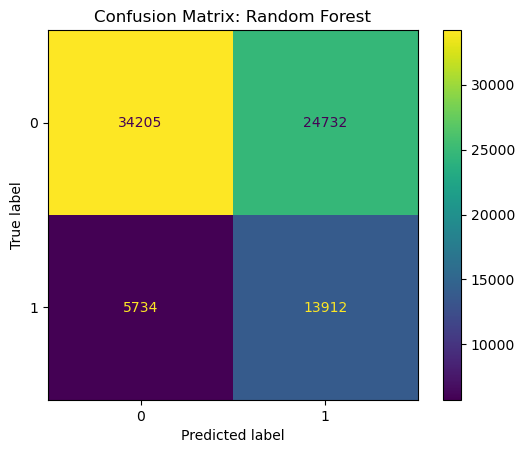

In [16]:
best_model_name = results_df.iloc[0]["model"]
best_pred = predictions[best_model_name]

print(f"Best model by recall: {best_model_name}")
print(classification_report(y_test, best_pred, zero_division=0))

cm = confusion_matrix(y_test, best_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Confusion Matrix: {best_model_name}")
plt.show()

## 17. ROC and Precision-Recall Curves

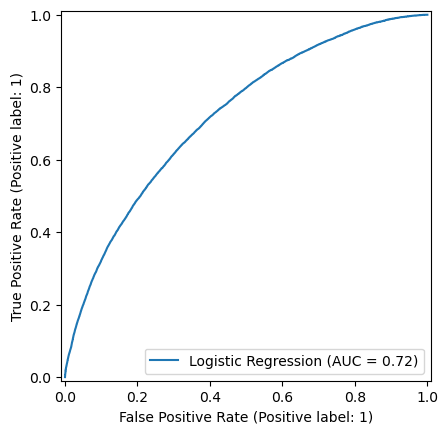

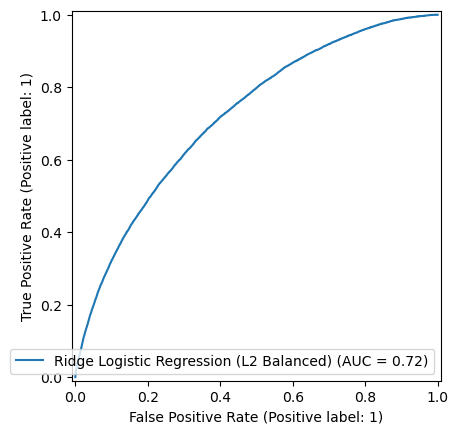

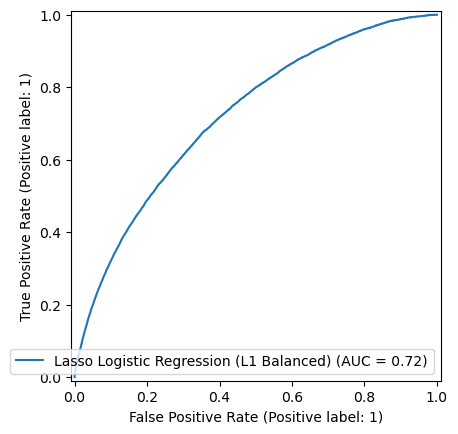

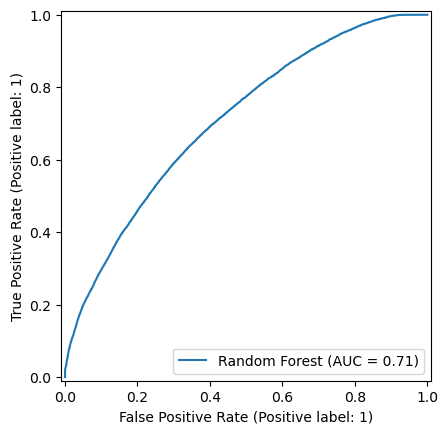

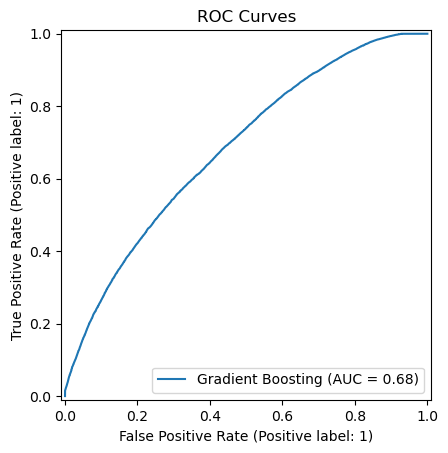

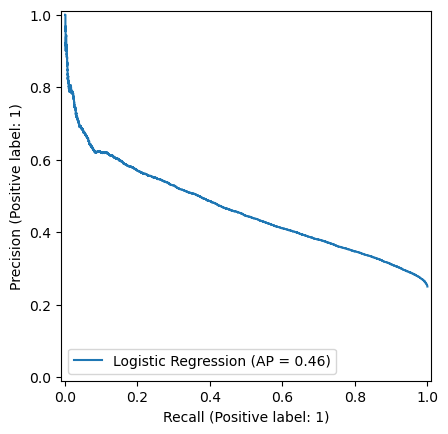

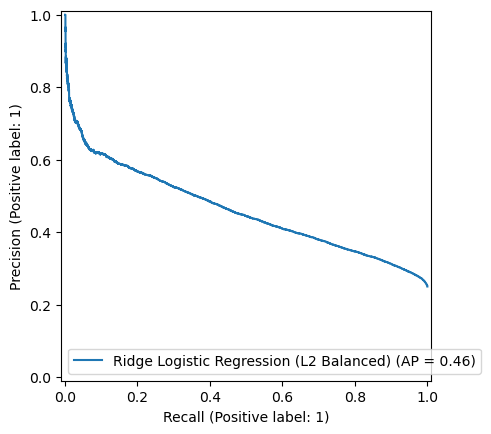

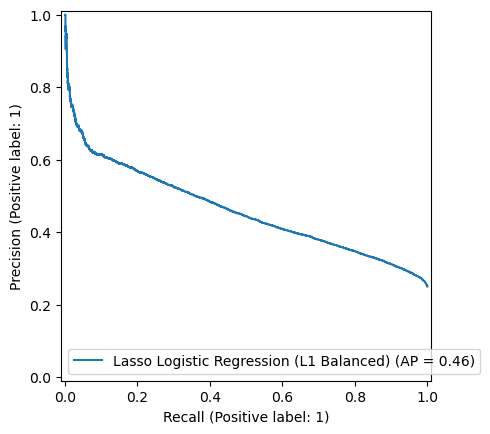

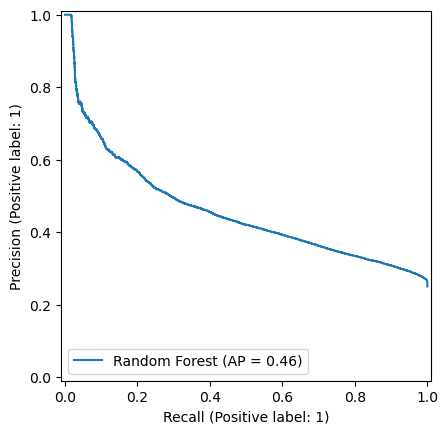

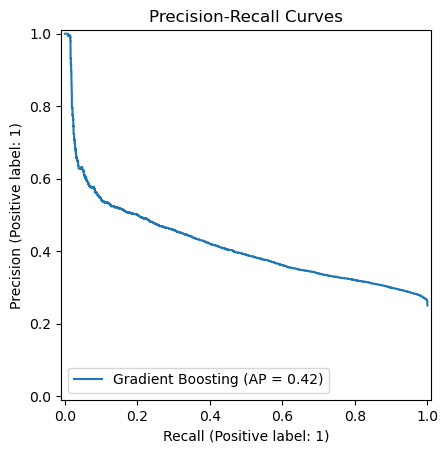

In [17]:
for name in trained_models:
    if probabilities[name] is not None:
        RocCurveDisplay.from_predictions(y_test, probabilities[name], name=name)

plt.title("ROC Curves")
plt.show()

for name in trained_models:
    if probabilities[name] is not None:
        PrecisionRecallDisplay.from_predictions(y_test, probabilities[name], name=name)

plt.title("Precision-Recall Curves")
plt.show()

## 18. Threshold Tuning

In [18]:
threshold_model_name = best_model_name
y_proba = probabilities[threshold_model_name]

threshold_results = []

if y_proba is not None:
    for threshold in np.arange(0.10, 0.91, 0.05):
        y_pred_threshold = (y_proba >= threshold).astype(int)

        threshold_results.append({
            "threshold": threshold,
            "precision": precision_score(y_test, y_pred_threshold, zero_division=0),
            "recall": recall_score(y_test, y_pred_threshold, zero_division=0),
            "f1": f1_score(y_test, y_pred_threshold, zero_division=0)
        })

    threshold_df = pd.DataFrame(threshold_results)
    display(threshold_df.sort_values(by="f1", ascending=False).head(10))
else:
    print("Selected model does not provide probabilities.")

,threshold,precision,recall,f1
8,0.50,0.360004,0.708134,0.477337
7,0.45,0.323250,0.839815,0.466819
6,0.40,0.304427,0.910771,0.456326
9,0.55,0.423190,0.490074,0.454183
5,0.35,0.291537,0.951644,0.446338
4,0.30,0.283034,0.973735,0.438585
3,0.25,0.276922,0.985748,0.432378
2,0.20,0.272090,0.992161,0.427063
1,0.15,0.267909,0.997506,0.422376
0,0.10,0.263949,0.999745,0.417636


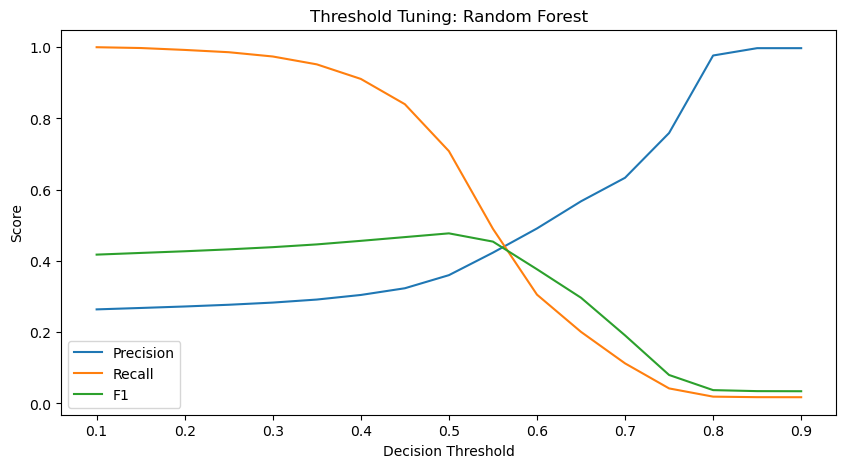

In [19]:
if y_proba is not None:
    plt.figure(figsize=(10, 5))
    plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
    plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
    plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
    plt.xlabel("Decision Threshold")
    plt.ylabel("Score")
    plt.title(f"Threshold Tuning: {threshold_model_name}")
    plt.legend()
    plt.show()

## 19. Lasso Coefficient Interpretation

In [20]:
lasso_name = "Lasso Logistic Regression (L1 Balanced)"

if lasso_name in trained_models:
    lasso_pipeline = trained_models[lasso_name]

    fitted_preprocessor = lasso_pipeline.named_steps["preprocessor"]
    fitted_model = lasso_pipeline.named_steps["model"]

    feature_names = fitted_preprocessor.get_feature_names_out()

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": fitted_model.coef_[0]
    })

    coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

    nonzero_coef_df = coef_df[coef_df["coefficient"] != 0].sort_values(
        by="abs_coefficient",
        ascending=False
    )

    print(f"Number of non-zero Lasso coefficients: {nonzero_coef_df.shape[0]}")
    display(nonzero_coef_df.head(20))

Number of non-zero Lasso coefficients: 6329


,feature,coefficient,abs_coefficient
11895,cat__industry_description_Repair highway road ...,-5.422076,5.422076
11942,cat__industry_description_Residential Property...,5.034565,5.034565
13392,cat__industry_description_Store,4.997052,4.997052
13606,cat__industry_description_Swimming pool supply...,4.471643,4.471643
318,cat__industry_description_531110 apartment rental,4.331734,4.331734
7005,cat__industry_description_Hog feedlots,4.084244,4.084244
10150,cat__industry_description_PARKING LOTS AND GAR...,-4.006569,4.006569
15315,cat__industry_description_janitorial Services,-3.883653,3.883653
13256,"cat__industry_description_Stage set (e.g., con...",-3.716118,3.716118
14980,cat__industry_description_Wholesale of profess...,3.606482,3.606482


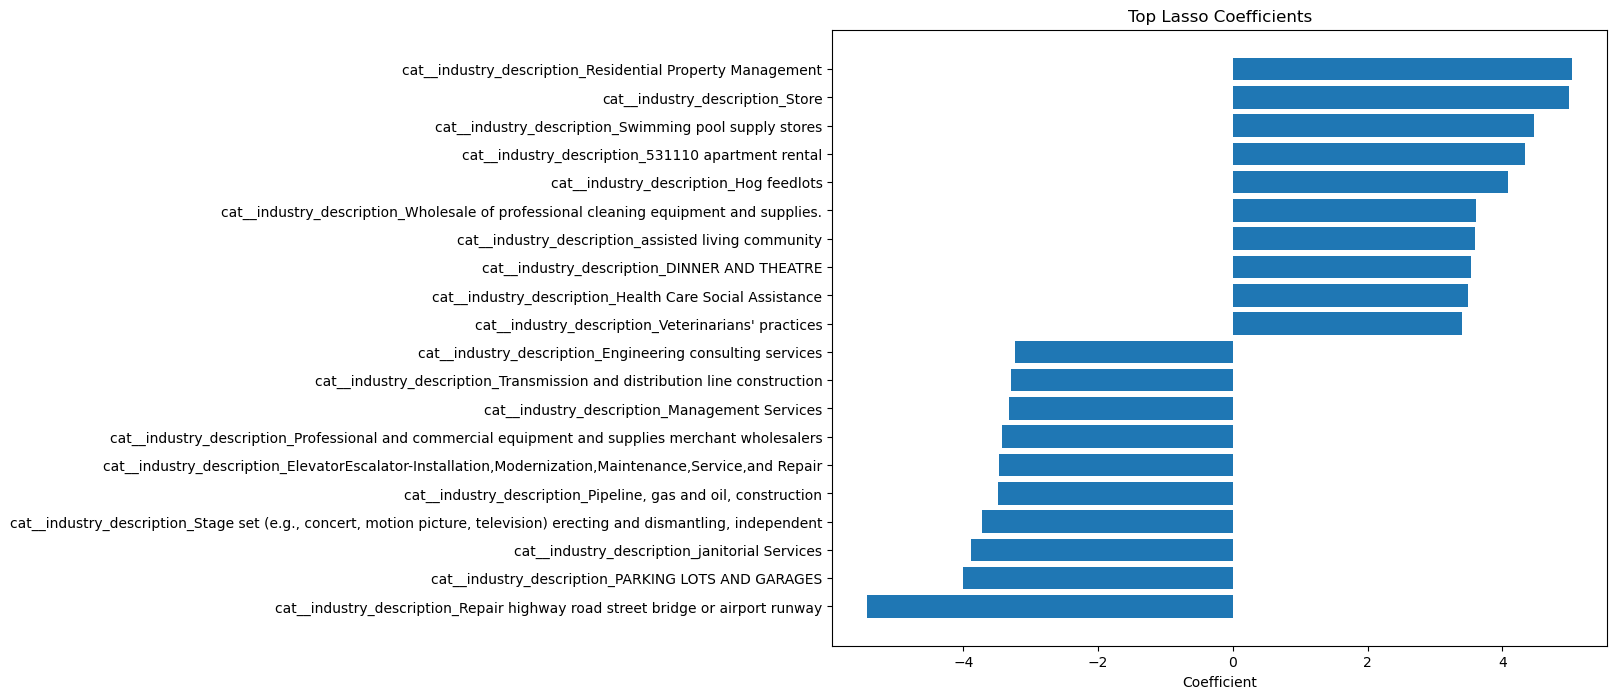

In [21]:
if lasso_name in trained_models and "nonzero_coef_df" in globals() and not nonzero_coef_df.empty:
    top_coef = nonzero_coef_df.head(20).sort_values("coefficient")

    plt.figure(figsize=(10, 8))
    plt.barh(top_coef["feature"], top_coef["coefficient"])
    plt.xlabel("Coefficient")
    plt.title("Top Lasso Coefficients")
    plt.show()

## 20. Random Forest Feature Importance

In [22]:
rf_name = "Random Forest"

if rf_name in trained_models:
    rf_pipeline = trained_models[rf_name]
    rf_preprocessor = rf_pipeline.named_steps["preprocessor"]
    rf_model = rf_pipeline.named_steps["model"]

    tree_feature_names = rf_preprocessor.get_feature_names_out()

    importance_df = pd.DataFrame({
        "feature": tree_feature_names,
        "importance": rf_model.feature_importances_
    }).sort_values(by="importance", ascending=False)

    display(importance_df.head(20))

,feature,importance
6,num__log_hours_worked,0.278638
4,num__naics_sector,0.186979
2,num__annual_average_employees,0.125400
8,cat__industry_description,0.110277
5,num__log_employees,0.100103
7,cat__state,0.059010
0,num__establishment_type,0.054310
10,cat__employee_size_bin,0.040275
1,num__size,0.036122
9,cat__size_category,0.008886


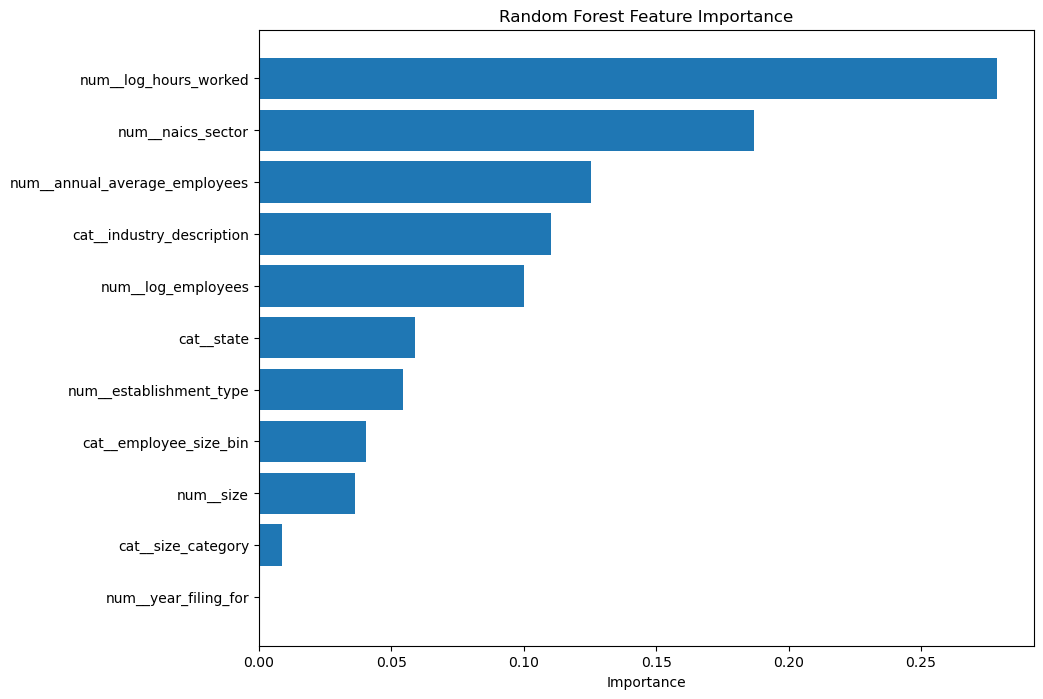

In [23]:
if "importance_df" in globals():
    top_importance = importance_df.head(20).sort_values("importance")

    plt.figure(figsize=(10, 8))
    plt.barh(top_importance["feature"], top_importance["importance"])
    plt.xlabel("Importance")
    plt.title("Random Forest Feature Importance")
    plt.show()

## 21. SHAP Explainability

SHAP is useful for explaining how features influence model predictions.

This section uses Random Forest because SHAP is especially useful for tree-based models.

In [24]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


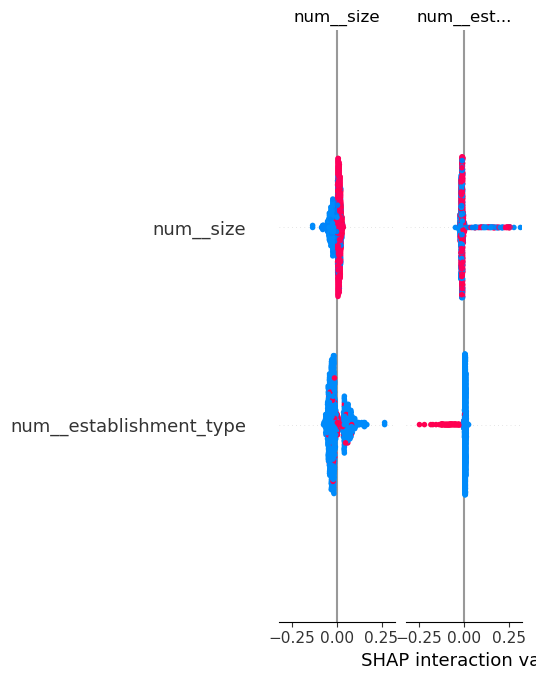

In [25]:


import shap
import numpy as np
import pandas as pd

shap_model_name = "Random Forest"
shap_pipeline = trained_models[shap_model_name]

X_sample = X_test.sample(
    n=min(1000, len(X_test)),
    random_state=RANDOM_STATE
)

preprocessor = shap_pipeline.named_steps["preprocessor"]
model = shap_pipeline.named_steps["model"]

X_sample_processed = preprocessor.transform(X_sample)

if hasattr(X_sample_processed, "toarray"):
    X_sample_processed = X_sample_processed.toarray()

feature_names = preprocessor.get_feature_names_out()

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample_processed)

if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values

shap.summary_plot(
    shap_values_to_plot,
    X_sample_processed,
    feature_names=feature_names
)

## Business Interpretation and Deployment Considerations

Because workplace safety prediction is a high-consequence problem, recall was prioritized throughout model evaluation. Missing a truly high-risk establishment could result in preventable injuries, operational disruptions, regulatory penalties, or delayed safety interventions. For this reason, the selected modeling approach emphasized identifying as many elevated-risk establishments as possible, even if this increased false positives.

Precision was also monitored to evaluate how many flagged establishments were likely to genuinely represent elevated safety risk. This metric helps organizations balance proactive intervention efforts with available inspection and safety management resources.

Threshold tuning demonstrated that model sensitivity can be adjusted depending on operational priorities. Lower thresholds improve recall and identify more potentially high-risk establishments, while higher thresholds reduce false positives and inspection workload. This flexibility allows organizations to adapt the model to staffing capacity and risk tolerance.

Model explainability techniques, including Lasso coefficient analysis, Random Forest feature importance, and SHAP explainability, were used to identify the operational and industry factors most associated with elevated workplace risk. These methods improve transparency and support stakeholder trust in the model’s recommendations.

The final model should be viewed as a decision-support tool rather than a replacement for workplace safety professionals. Its purpose is to help prioritize inspections, allocate resources more effectively, and support proactive safety management strategies.



Tableau Dashboard

https://public.tableau.com/views/WorkplaceSafetyDash/Dashboard1?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link
